In [12]:
%pip install matplotlib
%pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


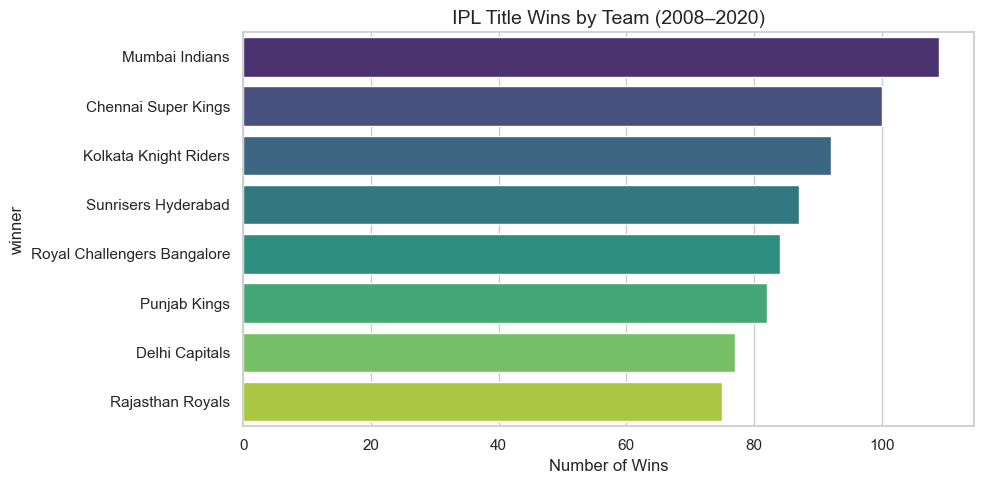

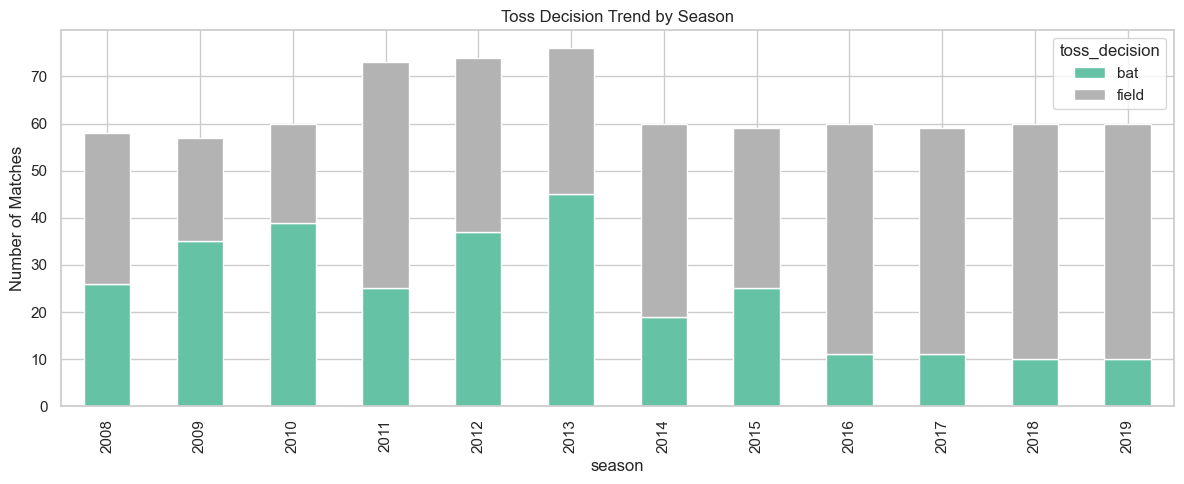

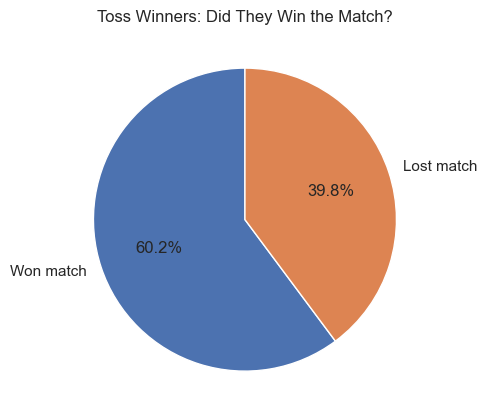

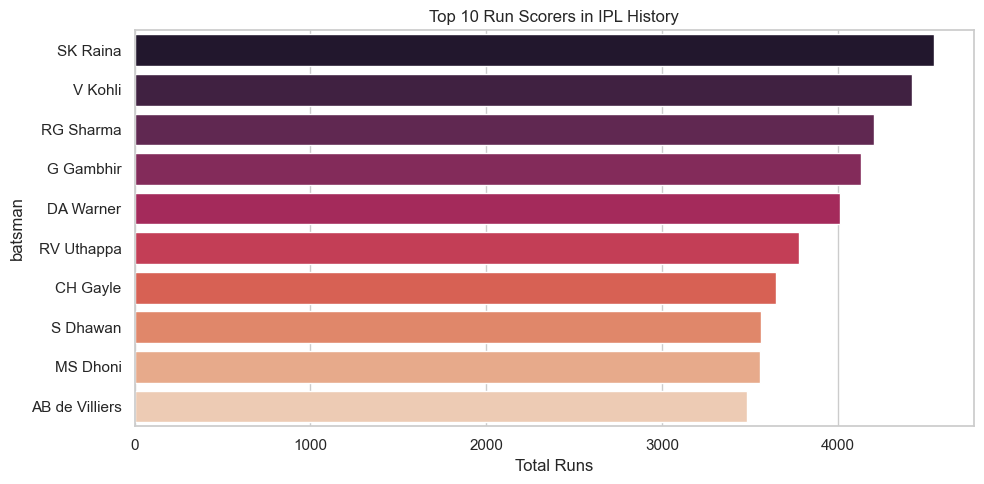

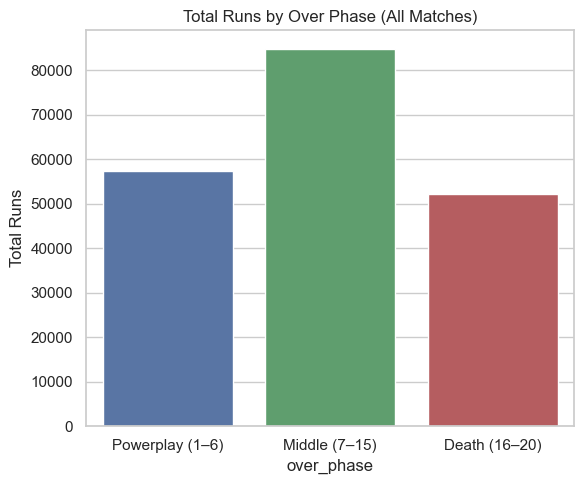

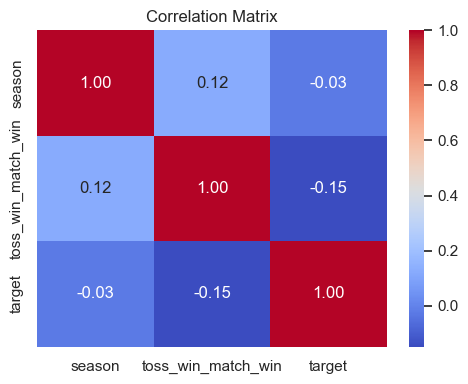

All EDA plots saved to outputs/plots/


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Setup
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs('../outputs/plots', exist_ok=True)

matches = pd.read_csv('../data/processed/matches_cleaned.csv')
deliveries = pd.read_csv('../data/processed/deliveries_cleaned.csv')

# ── Plot 1: Most IPL title wins by team ──────────────────────
winner_counts = matches['winner'].value_counts().head(8)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=winner_counts.values, y=winner_counts.index, hue=winner_counts.index, palette='viridis', ax=ax, legend=False)
ax.set_title('IPL Title Wins by Team (2008–2020)', fontsize=14)
ax.set_xlabel('Number of Wins')
plt.tight_layout()
plt.savefig('../outputs/plots/team_wins.png', dpi=150)
plt.show()

# ── Plot 2: Toss decision preference over seasons ────────────
toss_trend = matches.groupby(['season', 'toss_decision']).size().unstack()
toss_trend.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='Set2')
plt.title('Toss Decision Trend by Season')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.savefig('../outputs/plots/toss_trend.png', dpi=150)
plt.show()

# ── Plot 3: Toss win vs match win ─────────────────────────────
toss_effect = matches['toss_win_match_win'].value_counts()
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(toss_effect, labels=['Won match', 'Lost match'],
       autopct='%1.1f%%', startangle=90,
       colors=['#4C72B0', '#DD8452'])
ax.set_title('Toss Winners: Did They Win the Match?')
plt.tight_layout()
plt.savefig('../outputs/plots/toss_effect.png', dpi=150)
plt.show()

# ── Plot 4: Top 10 run scorers (career) ──────────────────────
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum()
top_batsmen = top_batsmen.nlargest(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, hue=top_batsmen.index, palette='rocket', ax=ax, legend=False)
ax.set_title('Top 10 Run Scorers in IPL History')
ax.set_xlabel('Total Runs')
plt.tight_layout()
plt.savefig('../outputs/plots/top_batsmen.png', dpi=150)
plt.show()

# ── Plot 5: Run distribution — powerplay vs death overs ──────
deliveries['over_phase'] = pd.cut(
    deliveries['over'], bins=[0, 6, 15, 20],
    labels=['Powerplay (1–6)', 'Middle (7–15)', 'Death (16–20)']
)
phase_runs = deliveries.groupby('over_phase', observed=False)['total_runs'].sum()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=phase_runs.index, y=phase_runs.values,
            hue=phase_runs.index, palette=['#4C72B0', '#55A868', '#C44E52'], ax=ax, legend=False)
ax.set_title('Total Runs by Over Phase (All Matches)')
ax.set_ylabel('Total Runs')
plt.tight_layout()
plt.savefig('../outputs/plots/over_phase_runs.png', dpi=150)
plt.show()

# ── Plot 6: Correlation heatmap (match-level features) ───────
match_feat = pd.read_csv('../data/processed/match_features.csv')
num_cols = match_feat[['season', 'toss_win_match_win', 'target']]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/plots/correlation_heatmap.png', dpi=150)
plt.show()

print("All EDA plots saved to outputs/plots/")